# Challenge 1: Semantic Segmentation using Convolutional Neural Networks (CNNs)

This notebook demonstrates the implementation of semantic segmentation using the U-Net architecture on a tomato dataset. Semantic segmentation is the task of assigning a class label to each pixel in an image, which is crucial for applications like medical imaging, autonomous driving, and agricultural monitoring.

**Key objectives:**
- Load and preprocess a tomato dataset with various directory structures
- Build a U-Net architecture for segmentation tasks
- Train the model using appropriate loss functions
- Evaluate the model performance
- Apply the model to segment new images

**Expected outcome:** A trained model that can accurately segment tomatoes from images, which could be used in agricultural applications.

## Setup and Prerequisites

First, let's import the necessary libraries and set up our environment.

In [1]:
#!pip install opencv-python

In [2]:
#!pip install segmentation-models

In [1]:
import zipfile
import os
def unzip_file(zip_path, extract_to='.'):
    """
    Unzips a zip file to the specified directory.
    
    Parameters:
    zip_path (str): The path to the zip file.
    extract_to (str): The directory to extract files to. Defaults to current directory.
    """
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted {zip_path} to {extract_to}")
# Example usage
zip_path = 'tomato.zip'  # Replace with your zip file path
extract_to = 'tomato'  # Replace with your desired extraction directory
unzip_file(zip_path, extract_to)


Extracted tomato.zip to tomato


In [3]:
# Fix for compatibility issues with segmentation_models and recent TensorFlow versions
import tensorflow as tf
import os
import sys

# Apply a patch for the missing generic_utils module
try:
    # First attempt: Check if the module exists
    import keras.utils.generic_utils
    print("keras.utils.generic_utils is available.")
except ImportError:
    try:
        # Create a patch for recent TensorFlow versions
        import keras
        
        # Patch the generic_utils functionality
        class GenericUtilsModule:
            @staticmethod
            def get_custom_objects():
                return tf.keras.utils.get_custom_objects()
        
        # Create the module path if it doesn't exist
        if not hasattr(keras, 'utils'):
            keras.utils = type('', (), {})()
        
        # Assign our custom module
        keras.utils.generic_utils = GenericUtilsModule()
        print("Successfully patched keras.utils.generic_utils for compatibility")
        
        # Monkey patch efficientnet to avoid additional issues
        sys.modules['efficientnet.keras'] = type('', (), {})()
        
        # Set segmentation_models to use tf.keras
        os.environ['SM_FRAMEWORK'] = 'tf.keras'
    except ImportError:
        # If the import fails, it might be an older TF version or a different issue.
        # The original error will likely persist if this patch doesn't apply or fails.
        print("Note: Failed to apply patch for tf.keras.utils.generic_utils. "
              "If 'AttributeError: ... generic_utils' persists, "
              "check TensorFlow and segmentation_models compatibility.")

Successfully patched keras.utils.generic_utils for compatibility


In [4]:

# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import cv2
from glob import glob
import random
from tqdm import tqdm
# Import segmentation_models after applying the patch
import segmentation_models as sm

# Set random seeds for reproducibility
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
random.seed(random_seed)

# Check for GPU availability
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Segmentation Models: using `tf.keras` framework.
TensorFlow version: 2.18.0
Num GPUs Available:  0


## 1. Load the Tomato Dataset

Let's load the tomato dataset with the actual directory structure. According to the directory listing, we have ['Mask', 'Mask2', 'Test', 'Test2', 'Train', 'Train2'] subdirectories.

In [ ]:
# Define the specific tomato data directories
TOMATO_BASE_DIR = "./tomato/tomato"

# Check if the tomato directory exists
if not os.path.exists(TOMATO_BASE_DIR):
    raise FileNotFoundError(f"Tomato directory not found at {os.path.abspath(TOMATO_BASE_DIR)}")

print(f"Tomato base directory found at: {os.path.abspath(TOMATO_BASE_DIR)}")

# List all subdirectories in the tomato directory
subdirs = [d for d in os.listdir(TOMATO_BASE_DIR) if os.path.isdir(os.path.join(TOMATO_BASE_DIR, d))]
print(f"Found subdirectories: {subdirs}")

# Identify image directories and mask directories based on naming patterns
image_dirs = []
mask_dirs = []

for subdir in subdirs:
    if subdir.startswith('Mask'):
        mask_dirs.append(os.path.join(TOMATO_BASE_DIR, subdir))
    elif subdir.startswith('Train') or subdir.startswith('Test'):
        image_dirs.append(os.path.join(TOMATO_BASE_DIR, subdir))

print(f"Image directories: {image_dirs}")
print(f"Mask directories: {mask_dirs}")

# Load all images from image directories
all_images = []
for img_dir in image_dirs:
    img_files = [os.path.join(img_dir, f) for f in os.listdir(img_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    all_images.extend(img_files)

# Load all masks from mask directories
all_masks = []
for mask_dir in mask_dirs:
    mask_files = [os.path.join(mask_dir, f) for f in os.listdir(mask_dir) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    all_masks.extend(mask_files)

# Sort to help with matching
all_images = sorted(all_images)
all_masks = sorted(all_masks)

print(f"Found {len(all_images)} images and {len(all_masks)} masks")

# Display some example file names
if all_images:
    print(f"Example image files: {[os.path.basename(f) for f in all_images[:3]]}")
if all_masks:
    print(f"Example mask files: {[os.path.basename(f) for f in all_masks[:3]]}")

# For further processing, we'll use these lists directly
IMAGES_DIR = all_images
MASKS_DIR = all_masks

Tomato base directory found at: c:\Users\USER\Graphics-and-Interaction-Techniques\Assignment2\Challenge1\tomato
Found subdirectories: ['Mask', 'Mask2', 'Test', 'Test2', 'Train', 'Train2']
Image directories: ['./tomato\\Test', './tomato\\Test2', './tomato\\Train', './tomato\\Train2']
Mask directories: ['./tomato\\Mask', './tomato\\Mask2']
Found 201 images and 100 masks
Example image files: ['Img1.jpg', 'Img10.jpg', 'Img11.jpg']
Example mask files: ['Img1.jpg', 'Img10.jpg', 'Img11.jpg']


Processing 201 images and 100 masks
Using only 100 pairs


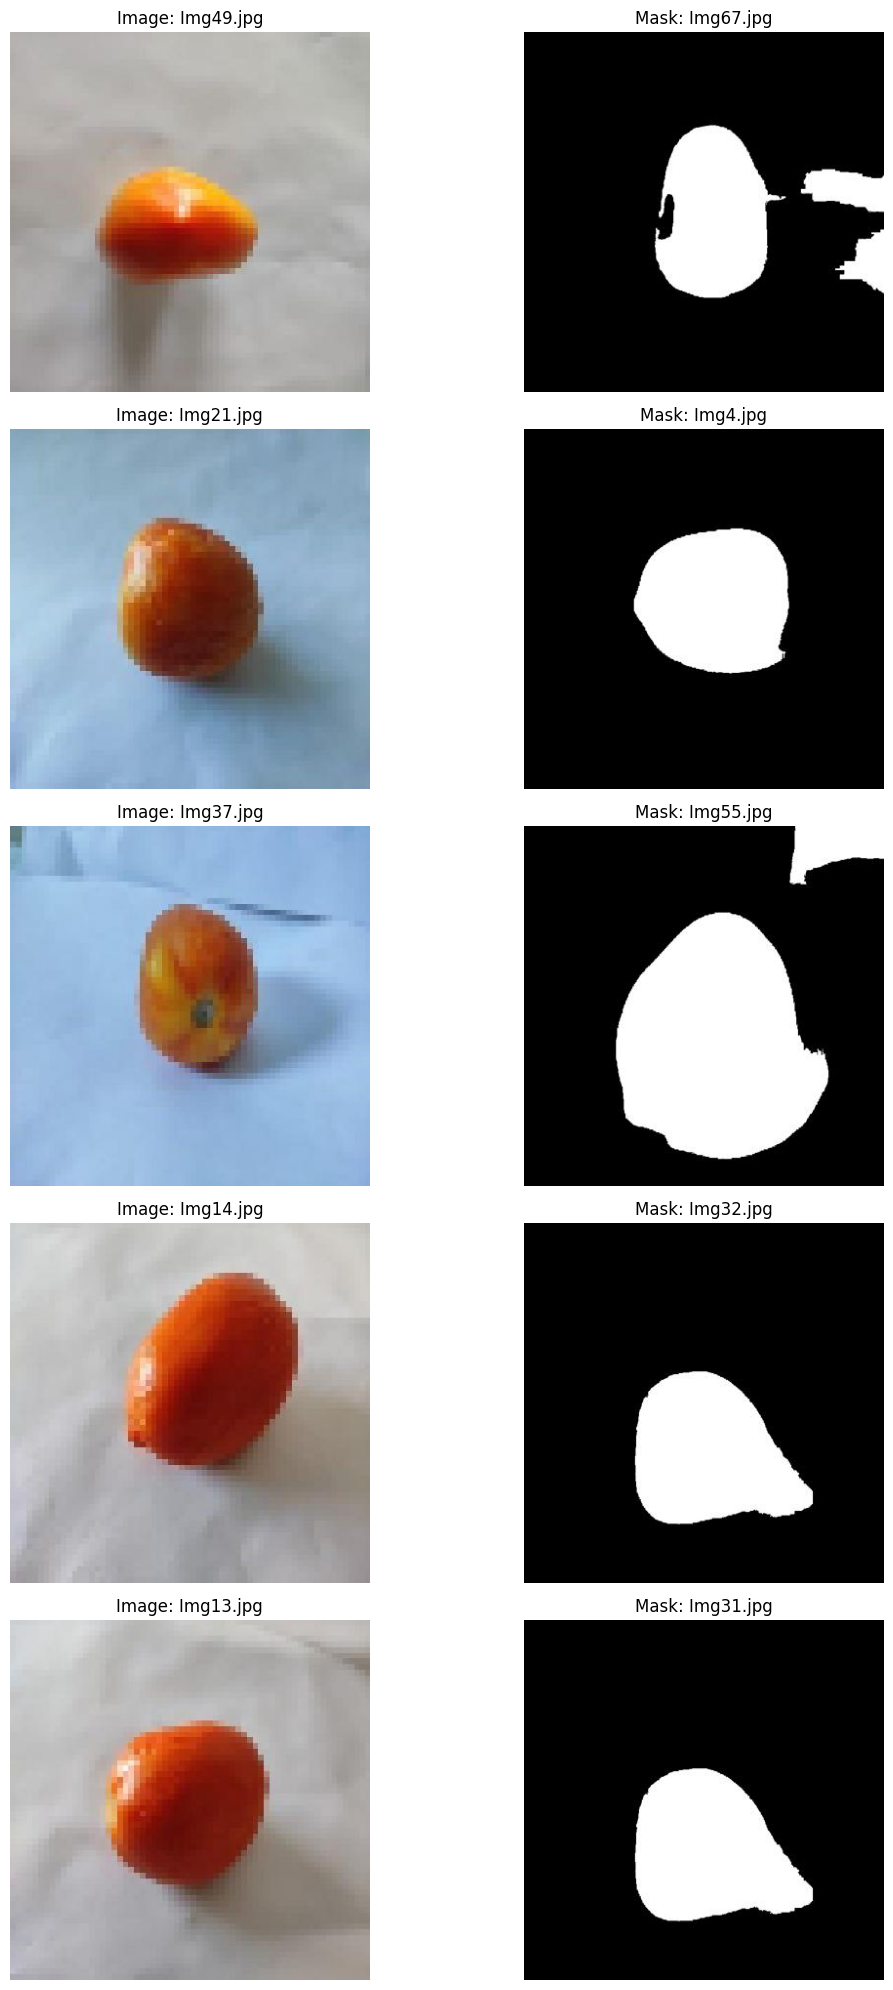

Successfully loaded images and masks!


In [6]:
# Function to load and preprocess images and masks
def load_data(image_paths, mask_paths, image_size=(256, 256)):
    # Since we're directly passing lists of file paths rather than directories,
    # we don't need to collect files using glob
    images = image_paths
    masks = mask_paths
    
    if not images:
        raise ValueError("No images provided")
    if not masks:
        raise ValueError("No masks provided")
    
    print(f"Processing {len(images)} images and {len(masks)} masks")
    
    # Check if the number of images matches the number of masks
    if len(images) != len(masks):
        print(f"Warning: Number of images ({len(images)}) doesn't match number of masks ({len(masks)})")
        # Use the minimum length to ensure pairs
        min_len = min(len(images), len(masks))
        images = images[:min_len]
        masks = masks[:min_len]
        print(f"Using only {min_len} pairs")
    
    # For demonstration purposes, let's load a small subset to display
    num_samples = min(5, len(images))
    sample_indices = np.random.choice(len(images), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))
    
    # Handle case where only one sample is shown
    if num_samples == 1:
        axes = [axes]
    
    for i, idx in enumerate(sample_indices):
        # Load and display image
        img = cv2.imread(images[idx])
        if img is None:
            print(f"Error reading image: {images[idx]}")
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i][0].imshow(img)
        axes[i][0].set_title(f"Image: {os.path.basename(images[idx])}")
        axes[i][0].axis('off')
        
        # Load and display mask
        mask = cv2.imread(masks[idx], cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Error reading mask: {masks[idx]}")
            continue
            
        axes[i][1].imshow(mask, cmap='gray')
        axes[i][1].set_title(f"Mask: {os.path.basename(masks[idx])}")
        axes[i][1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return images, masks

# Load data paths
try:
    image_paths, mask_paths = load_data(IMAGES_DIR, MASKS_DIR)
    print("Successfully loaded images and masks!")
except Exception as e:
    print(f"Error loading images and masks: {e}")
    raise

# Function to help visualize processed samples
def visualize_processed_samples(generator, num_samples=3):
    plt.figure(figsize=(12, 4*num_samples))
    
    for i in range(num_samples):
        # Get a batch
        X_batch, y_batch = generator.__getitem__(i)
        
        # Get the first sample from the batch
        img = X_batch[0]
        mask = y_batch[0].squeeze()
        
        # Display
        plt.subplot(num_samples, 3, i*3+1)
        plt.imshow(img)
        plt.title(f"Processed Image {i+1}")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3+2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Processed Mask {i+1}")
        plt.axis('off')
        
        plt.subplot(num_samples, 3, i*3+3)
        # Overlay mask on image for visualization
        overlay = img.copy()
        overlay[:, :, 0] = np.where(mask > 0.5, 1, overlay[:, :, 0])
        plt.imshow(overlay)
        plt.title(f"Overlay {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## 3. Split Dataset into Training, Validation, and Testing Sets

We'll divide our dataset into three parts:
- Training set: Used to train the model (typically 70-80% of data)
- Validation set: Used for hyperparameter tuning (typically 10-15% of data)
- Testing set: Used for final model evaluation (typically 10-15% of data)

In [7]:
def split_dataset(image_paths, mask_paths, val_size=0.15, test_size=0.15):
    # First split: separate test set
    x_train_val, x_test, y_train_val, y_test = train_test_split(
        image_paths, mask_paths, test_size=test_size, random_state=42
    )
    
    # Second split: separate validation set from training set
    # Adjusted validation size to get the desired proportion from the remaining data
    adjusted_val_size = val_size / (1 - test_size)
    x_train, x_val, y_train, y_val = train_test_split(
        x_train_val, y_train_val, test_size=adjusted_val_size, random_state=42
    )
    
    print(f"Training set: {len(x_train)} images")
    print(f"Validation set: {len(x_val)} images")
    print(f"Testing set: {len(x_test)} images")
    
    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

# Split the dataset
# Uncomment when dataset is available
(train_img_paths, train_mask_paths), (val_img_paths, val_mask_paths), (test_img_paths, test_mask_paths) = split_dataset(image_paths, mask_paths)

Training set: 69 images
Validation set: 16 images
Testing set: 15 images


## 4. Understanding the U-Net Architecture

U-Net is a popular convolutional neural network architecture designed specifically for biomedical image segmentation tasks. Published in 2015 by Ronneberger et al., it has become a standard approach for various segmentation problems beyond medical imaging.

The architecture forms a distinctive "U" shape consisting of:

1. **Encoder/Contracting Path**: A series of convolutional and max pooling layers that capture context and reduce spatial dimensions. This path works similar to a traditional CNN, extracting features while decreasing resolution.
   - Each step in this path doubles the number of feature channels

2. **Bottleneck**: The middle part connecting the encoder and decoder, representing the lowest resolution with highest feature complexity.

3. **Decoder/Expanding Path**: A series of upsampling (transpose convolution) and convolutional layers that restore spatial dimensions while preserving semantic information.
   - Each step halves the number of feature channels

4. **Skip Connections**: One of the key innovations of U-Net - direct connections between corresponding encoder and decoder layers that help preserve spatial information that would otherwise be lost during downsampling.
   - These connections concatenate feature maps from the encoder to the decoder

This architecture is particularly effective for segmentation tasks because it combines:
- Low-level spatial information (edges, textures) from the encoder's early layers
- High-level semantic information (object parts, context) from the bottleneck
- Precise localization through the skip connections

![U-Net Architecture](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

*Source: O. Ronneberger, P. Fischer, and T. Brox, "U-Net: Convolutional Networks for Biomedical Image Segmentation," MICCAI 2015.*

## 5. Implement the U-Net Architecture

Now we'll implement the U-Net architecture using TensorFlow/Keras. We'll define a function to create the U-Net model.

In [8]:
def build_unet_model(input_size=(256, 256, 3), n_classes=1):
    """
    Build a U-Net model for semantic segmentation
    
    Parameters:
    - input_size: Tuple of (height, width, channels) for input images
    - n_classes: Number of output classes (1 for binary segmentation)
    
    Returns:
    - U-Net model
    """
    # Input layer
    inputs = keras.Input(shape=input_size)
    
    # Encoder path (downsampling)
    # Block 1
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    
    # Block 2
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    
    # Block 3
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)
    
    # Block 4
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)
    
    # Bottleneck
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)
    
    # Decoder path (upsampling)
    # Block 6
    up6 = layers.Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(conv5)
    concat6 = layers.Concatenate()([up6, conv4])
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(concat6)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)
    
    # Block 7
    up7 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv6)
    concat7 = layers.Concatenate()([up7, conv3])
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(concat7)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)
    
    # Block 8
    up8 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv7)
    concat8 = layers.Concatenate()([up8, conv2])
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat8)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)
    
    # Block 9
    up9 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv8)
    concat9 = layers.Concatenate()([up9, conv1])
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat9)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)
    
    # Output layer
    if n_classes == 1:  # Binary segmentation
        outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv9)
    else:  # Multi-class segmentation
        outputs = layers.Conv2D(n_classes, 1, activation='softmax')(conv9)
    
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    return model

# Alternative: Using a pre-trained model from segmentation_models library
def build_pretrained_unet(backbone='resnet34', input_size=(256, 256, 3), n_classes=1):
    """
    Build a U-Net model with a pre-trained backbone
    
    Parameters:
    - backbone: Name of the backbone (e.g., 'resnet34', 'efficientnetb0')
    - input_size: Tuple of (height, width, channels) for input images
    - n_classes: Number of output classes
    
    Returns:
    - U-Net model with pre-trained backbone
    """
    if n_classes == 1:
        activation = 'sigmoid'
    else:
        activation = 'softmax'
        
    model = sm.Unet(
        backbone_name=backbone,
        input_shape=input_size,
        classes=n_classes,
        activation=activation,
        encoder_weights='imagenet'  # Pre-trained on ImageNet
    )
    
    return model

# Create the U-Net model
input_size = (256, 256, 3)  # Adjust based on your data
n_classes = 1  # Binary segmentation (tomato vs background)

# Choose one of the model building options
model = build_unet_model(input_size, n_classes)
# Alternatively, use pre-trained model (uncomment below)
# model = build_pretrained_unet('resnet34', input_size, n_classes)

# Display model summary
model.summary()

# Visualize the model architecture
tf.keras.utils.plot_model(model, to_file='unet_architecture.png', show_shapes=True, show_layer_names=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 6. Preprocess Input Images and Ground Truth Masks

Before training, we need to preprocess our images and masks to ensure they are in the correct format for the model.

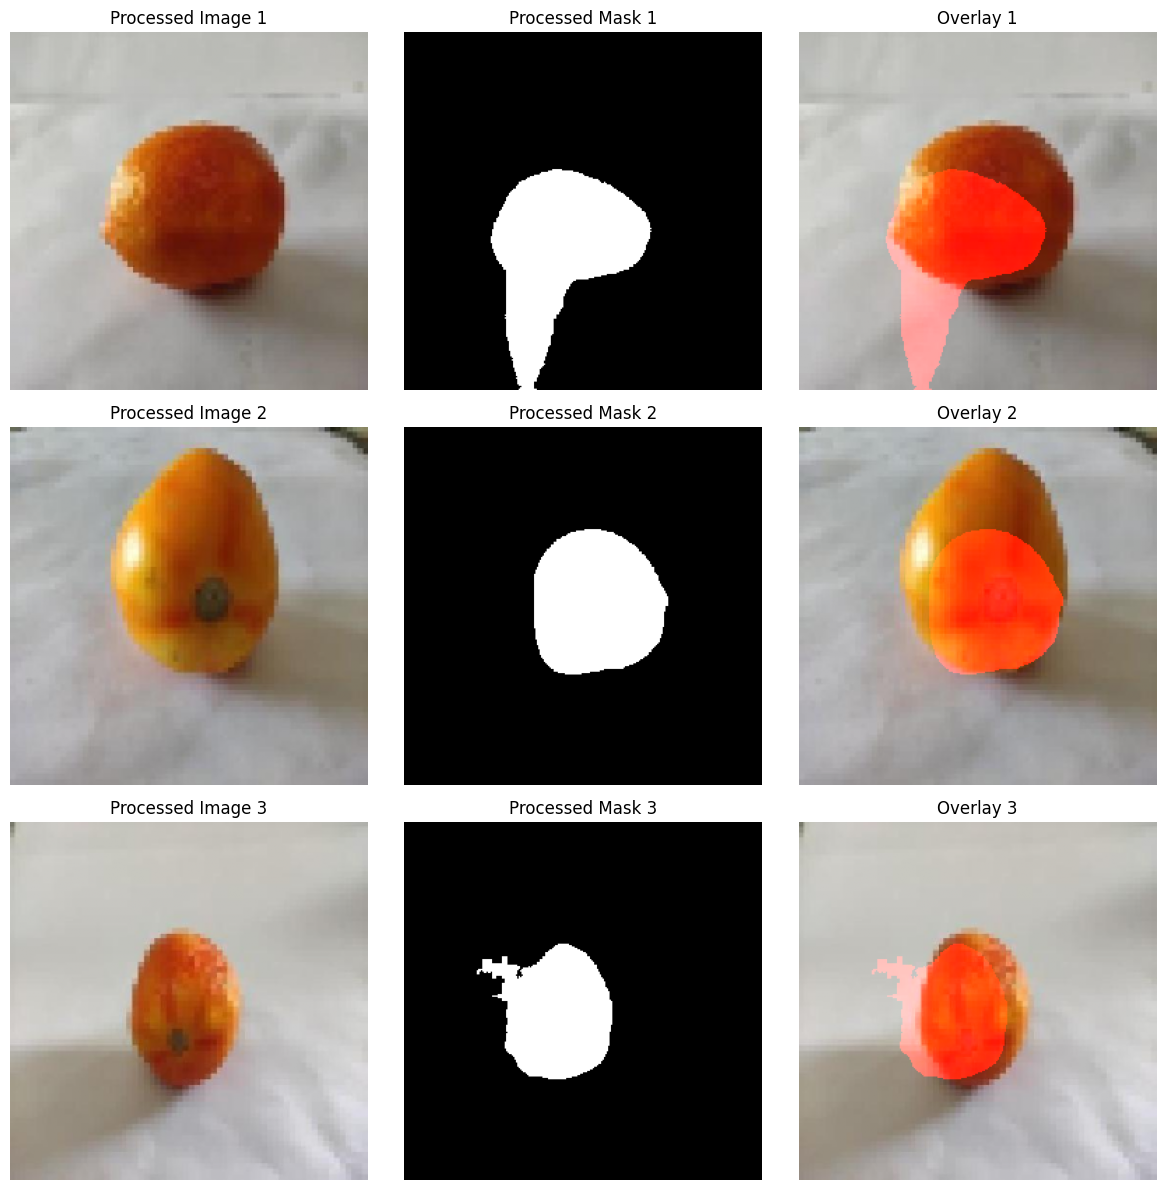

In [9]:
def preprocess_data(img_path, mask_path, img_size=(256, 256)):
    """
    Load and preprocess an image and its mask
    
    Parameters:
    - img_path: Path to the image file
    - mask_path: Path to the mask file
    - img_size: Target size for the image and mask
    
    Returns:
    - Preprocessed image and mask
    """
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Load mask (grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize
    img = cv2.resize(img, img_size)
    mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)  # Use nearest neighbor for masks
    
    # Normalize image to [0, 1]
    img = img / 255.0
    
    # Binarize mask (if not already binary)
    mask = (mask > 127).astype(np.float32)
    
    # Expand dimensions for the mask to match model output shape
    mask = np.expand_dims(mask, axis=-1)
    
    return img, mask

# Data generator for training and validation
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=8, img_size=(256, 256), augmentation=False, shuffle=True):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.on_epoch_end()
        
    def __len__(self):
        return int(np.ceil(len(self.img_paths) / self.batch_size))
    
    def __getitem__(self, index):
        # Generate indexes for this batch
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        
        # Get list of image paths for this batch
        batch_img_paths = [self.img_paths[i] for i in batch_indexes]
        batch_mask_paths = [self.mask_paths[i] for i in batch_indexes]
        
        # Generate data
        X, y = self.__generate_batch(batch_img_paths, batch_mask_paths)
        
        return X, y
    
    def on_epoch_end(self):
        self.indexes = np.arange(len(self.img_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __generate_batch(self, batch_img_paths, batch_mask_paths):
        X = np.empty((len(batch_img_paths), *self.img_size, 3))
        y = np.empty((len(batch_img_paths), *self.img_size, 1))
        
        for i, (img_path, mask_path) in enumerate(zip(batch_img_paths, batch_mask_paths)):
            img, mask = preprocess_data(img_path, mask_path, self.img_size)
            
            if self.augmentation:
                # Apply augmentation (example: random flip)
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                    mask = np.fliplr(mask)
                
                # Add more augmentations as needed
            
            X[i,] = img
            y[i,] = mask
            
        return X, y

# Create data generators
# Uncomment when dataset is available
train_generator = DataGenerator(train_img_paths, train_mask_paths, batch_size=8, augmentation=True)
val_generator = DataGenerator(val_img_paths, val_mask_paths, batch_size=8, augmentation=False)
test_generator = DataGenerator(test_img_paths, test_mask_paths, batch_size=8, augmentation=False, shuffle=False)

# Visualize some processed samples
# Uncomment when data generators are available
visualize_processed_samples(train_generator)

## 7-10. Train the U-Net Model

Now we'll train the U-Net model using our training and validation datasets. We'll:
- Define appropriate loss functions for segmentation
- Set up optimization techniques
- Configure callbacks to monitor training
- Implement early stopping to prevent overfitting

c:\Users\USER\anaconda3\envs\git\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45s/step - binary_accuracy: 0.4521 - dice_coefficient: 0.2124 - loss: 1.4821 
Epoch 1: val_dice_coefficient improved from -inf to 0.26032, saving model to best_unet_model.h5

Epoch 1: val_dice_coefficient improved from -inf to 0.26032, saving model to best_unet_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 450s 49s/step - binary_accuracy: 0.4760 - dice_coefficient: 0.2132 - loss: 1.4797 - val_binary_accuracy: 0.8311 - val_dice_coefficient: 0.2603 - val_loss: 1.3941 - learning_rate: 1.0000e-04
Epoch 2/2
Epoch 2/2
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53s/step - binary_accuracy: 0.8611 - dice_coefficient: 0.2242 - loss: 1.4180 
Epoch 2: val_dice_coefficient improved from 0.26032 to 0.26308, saving model to best_unet_model.h5

Epoch 2: val_dice_coefficient improved from 0.26032 to 0.26308, saving model to best_unet_model.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 470s 55s/step - binary_accuracy: 0.8610 - dice_coefficient: 0.2241 - loss: 1.4167 - val_binary_accuracy: 0.8258 - val_dice_coefficient: 0.2631 - val_loss: 1.3344 - learning_rate: 1.0000e-04


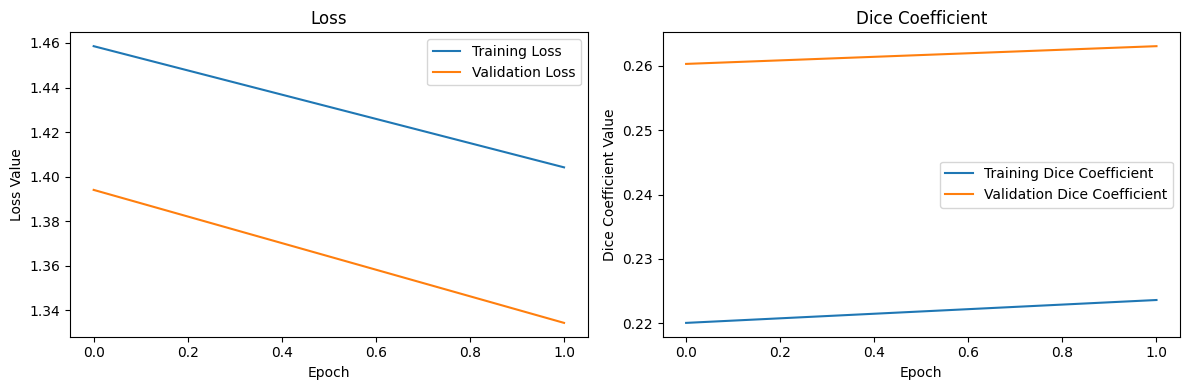

In [10]:
# Define custom loss functions for segmentation
def dice_loss(y_true, y_pred, smooth=1):
    """
    Dice loss for segmentation tasks
    """
    # Ensure both inputs have the same data type (float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_coefficient(y_true, y_pred, smooth=1):
    """
    Dice coefficient for evaluation
    """
    # Ensure both inputs have the same data type (float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
    """
    Combination of binary cross-entropy and dice loss
    """
    # Ensure both inputs have the same data type (float32)
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# Define model compile options
optimizer = Adam(learning_rate=1e-4)
metrics = [dice_coefficient, 'binary_accuracy']

# Compile the model
model.compile(optimizer=optimizer, loss=combined_loss, metrics=metrics)

# Set up callbacks
callbacks = [
    ModelCheckpoint('best_unet_model.h5', monitor='val_dice_coefficient', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-6)
]

# Train the model
# Uncomment when data generators are available
EPOCHS = 2
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Define function to plot training history
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Value')
    plt.legend()
    
    # Plot dice coefficient
    plt.subplot(1, 2, 2)
    plt.plot(history.history['dice_coefficient'], label='Training Dice Coefficient')
    plt.plot(history.history['val_dice_coefficient'], label='Validation Dice Coefficient')
    plt.title('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient Value')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Uncomment when training is done
plot_training_history(history)

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - binary_accuracy: 0.8294 - dice_coefficient: 0.2590 - loss: 1.3364
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 6s/step - binary_accuracy: 0.8294 - dice_coefficient: 0.2590 - loss: 1.3364
Test Loss: 1.3350
Test Dice Coefficient: 0.2584
Test Accuracy: 0.8308
Test Loss: 1.3350
Test Dice Coefficient: 0.2584
Test Accuracy: 0.8308
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


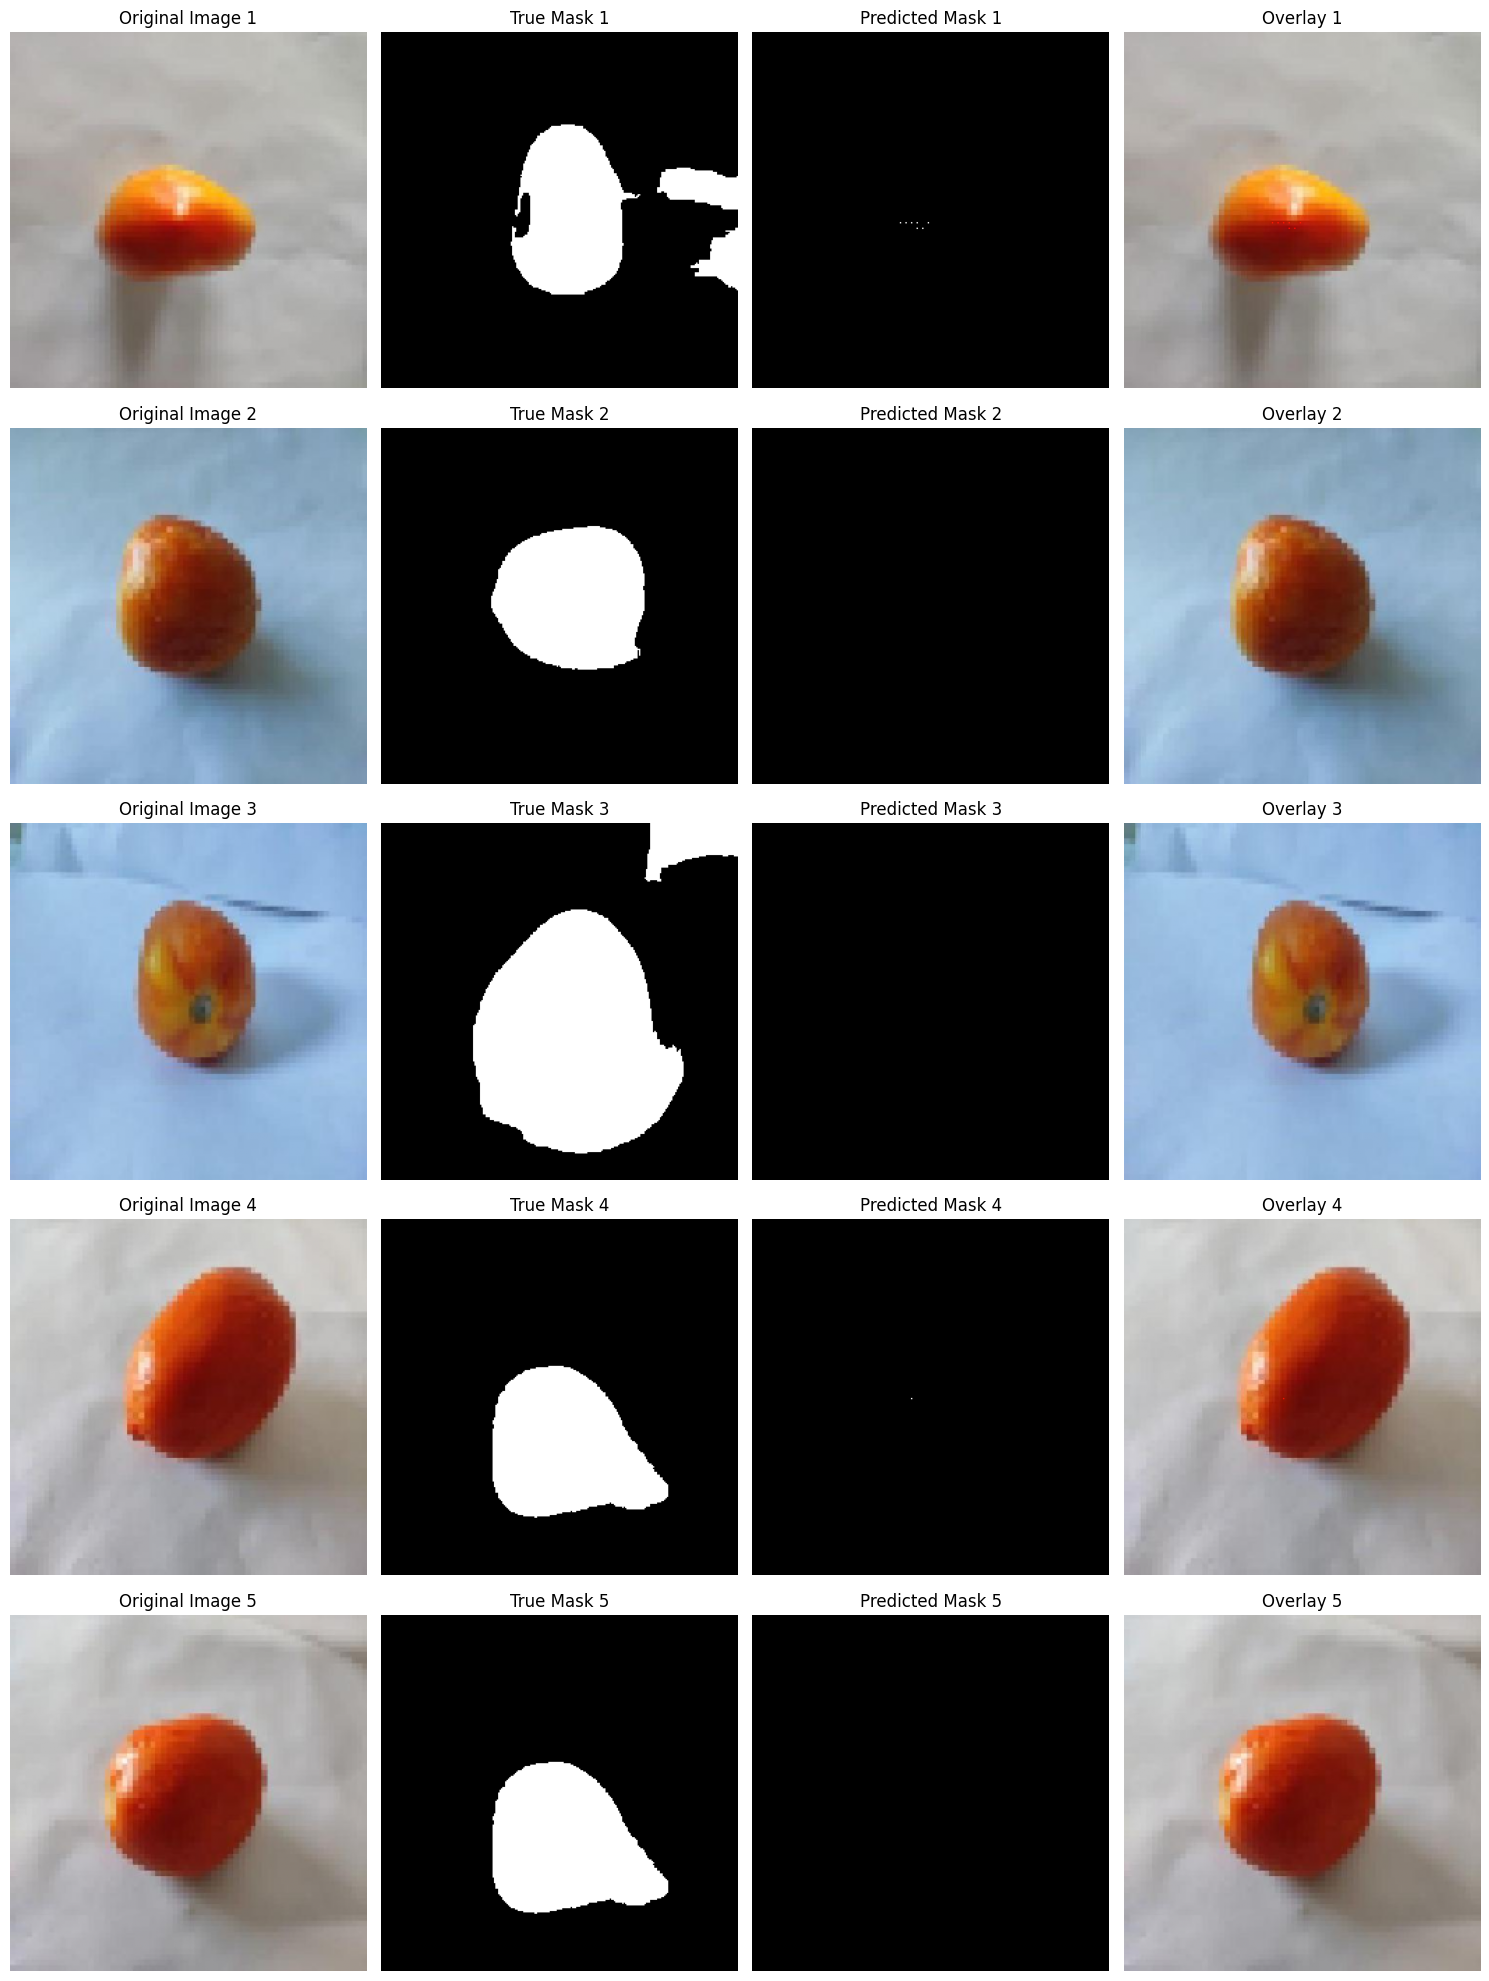

In [11]:
# Load the best model
# Uncomment when model is trained
model = keras.models.load_model('best_unet_model.h5', custom_objects={
    'dice_coefficient': dice_coefficient,
    'dice_loss': dice_loss,
    'combined_loss': combined_loss
})

# Evaluate on test set
# Uncomment when test data is available
test_results = model.evaluate(test_generator)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test Accuracy: {test_results[2]:.4f}")

# Function to predict masks for a batch of images
def predict_masks(model, batch_images):
    """
    Predict masks for a batch of images
    
    Parameters:
    - model: Trained U-Net model
    - batch_images: Batch of preprocessed images
    
    Returns:
    - Predicted masks
    """
    return model.predict(batch_images)

# Function to visualize results
def visualize_results(model, test_generator, num_samples=5):
    """
    Visualize segmentation results
    
    Parameters:
    - model: Trained U-Net model
    - test_generator: Generator for test data
    - num_samples: Number of samples to visualize
    """
    # Get a batch of test data
    X_test, y_true = test_generator.__getitem__(0)
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Display results
    plt.figure(figsize=(15, 4*num_samples))
    
    for i in range(min(num_samples, len(X_test))):
        # Original image
        plt.subplot(num_samples, 4, i*4+1)
        plt.imshow(X_test[i])
        plt.title(f"Original Image {i+1}")
        plt.axis('off')
        
        # True mask
        plt.subplot(num_samples, 4, i*4+2)
        plt.imshow(y_true[i].squeeze(), cmap='gray')
        plt.title(f"True Mask {i+1}")
        plt.axis('off')
        
        # Predicted mask
        plt.subplot(num_samples, 4, i*4+3)
        plt.imshow(y_pred[i].squeeze() > 0.5, cmap='gray')
        plt.title(f"Predicted Mask {i+1}")
        plt.axis('off')
        
        # Overlay prediction on original image
        plt.subplot(num_samples, 4, i*4+4)
        overlay = X_test[i].copy()
        pred_mask = y_pred[i].squeeze() > 0.5
        overlay[:, :, 0] = np.where(pred_mask, 1, overlay[:, :, 0])  # Red channel for prediction
        plt.imshow(overlay)
        plt.title(f"Overlay {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Uncomment when model and test data are available
visualize_results(model, test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


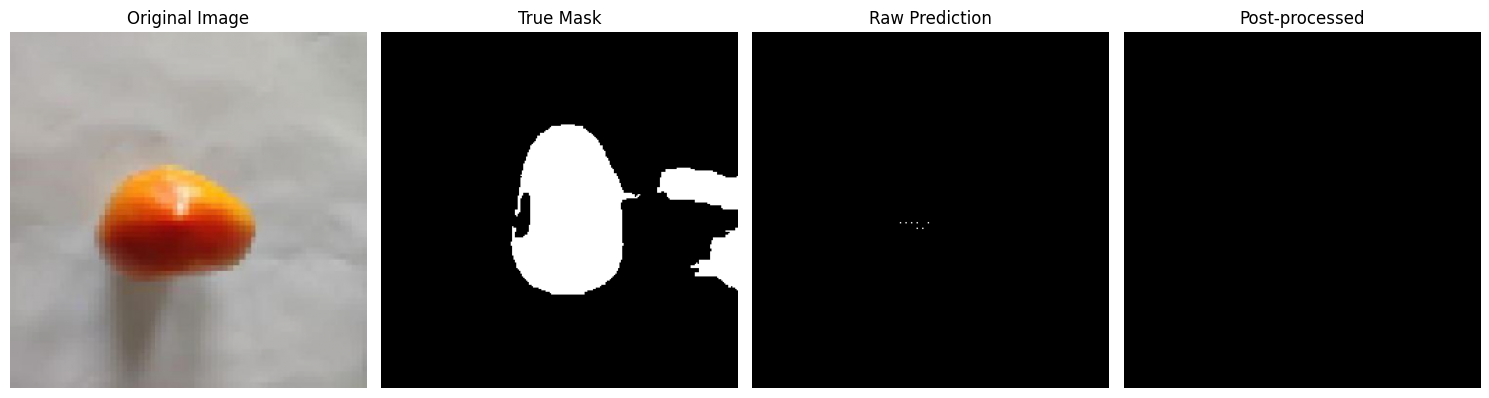

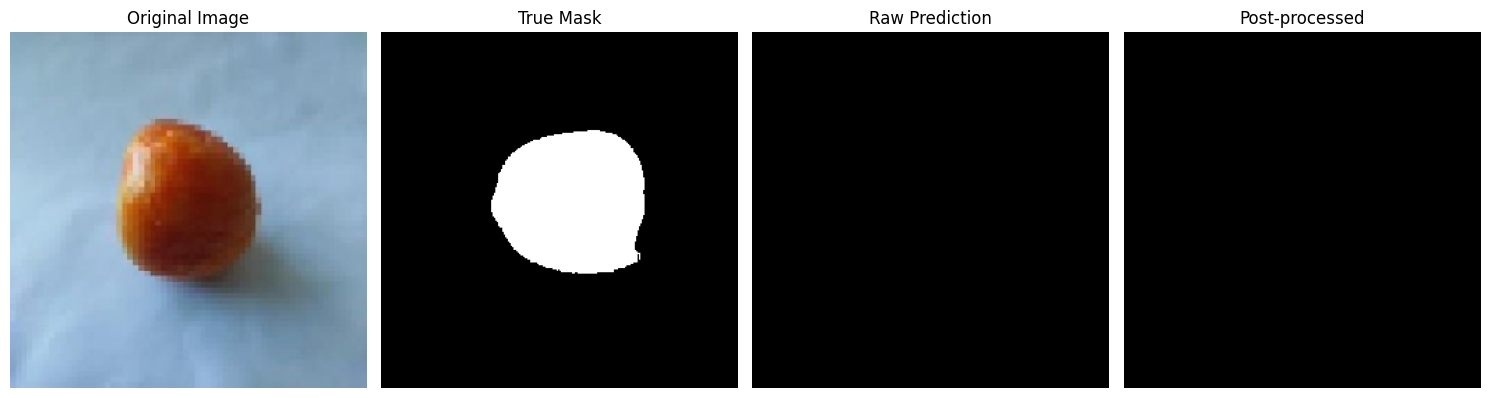

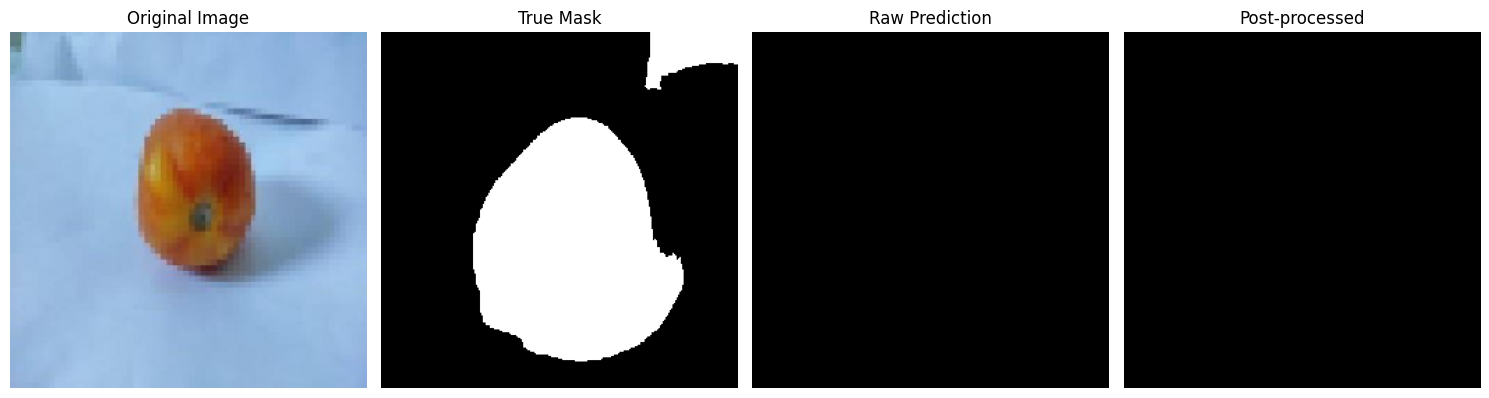

In [12]:
def post_process_mask(mask, min_size=100):
    """
    Apply post-processing to the predicted mask
    
    Parameters:
    - mask: Predicted binary mask
    - min_size: Minimum connected component size to retain
    
    Returns:
    - Post-processed mask
    """
    # Convert to binary
    binary_mask = (mask > 0.5).astype(np.uint8)
    
    # Apply morphological operations
    kernel = np.ones((5, 5), np.uint8)
    opening = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Remove small connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closing, connectivity=8)
    
    # Create a new mask with only large connected components
    processed_mask = np.zeros_like(closing)
    
    # Start from 1 to skip background
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            processed_mask[labels == i] = 1
    
    return processed_mask

# Function to compare original and post-processed masks
def compare_post_processing(original_image, true_mask, predicted_mask):
    """
    Compare original and post-processed segmentation results
    
    Parameters:
    - original_image: Original input image
    - true_mask: Ground truth segmentation mask
    - predicted_mask: Raw predicted mask from the model
    """
    # Convert predicted mask to binary
    binary_pred = (predicted_mask > 0.5).astype(np.uint8)
    
    # Apply post-processing
    post_processed = post_process_mask(predicted_mask)
    
    # Display results
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 4, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')
    
    # True mask
    plt.subplot(1, 4, 2)
    plt.imshow(true_mask.squeeze(), cmap='gray')
    plt.title("True Mask")
    plt.axis('off')
    
    # Raw prediction
    plt.subplot(1, 4, 3)
    plt.imshow(binary_pred.squeeze(), cmap='gray')
    plt.title("Raw Prediction")
    plt.axis('off')
    
    # Post-processed prediction
    plt.subplot(1, 4, 4)
    plt.imshow(post_processed, cmap='gray')
    plt.title("Post-processed")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Uncomment when model and test data are available
X_test, y_true = test_generator.__getitem__(0)
y_pred = model.predict(X_test)
for i in range(3):
    compare_post_processing(X_test[i], y_true[i], y_pred[i])

Using a random image from the test set instead...
Selected image: Img3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


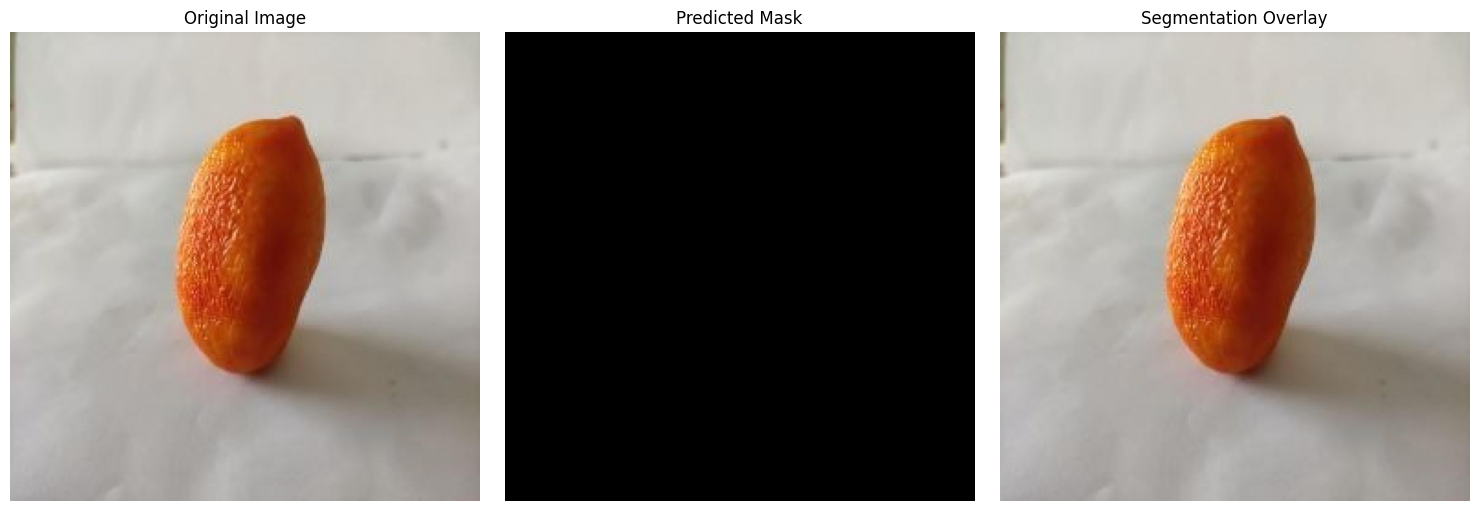


Example 1:
Using a random image from the test set instead...
Selected image: Img55.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


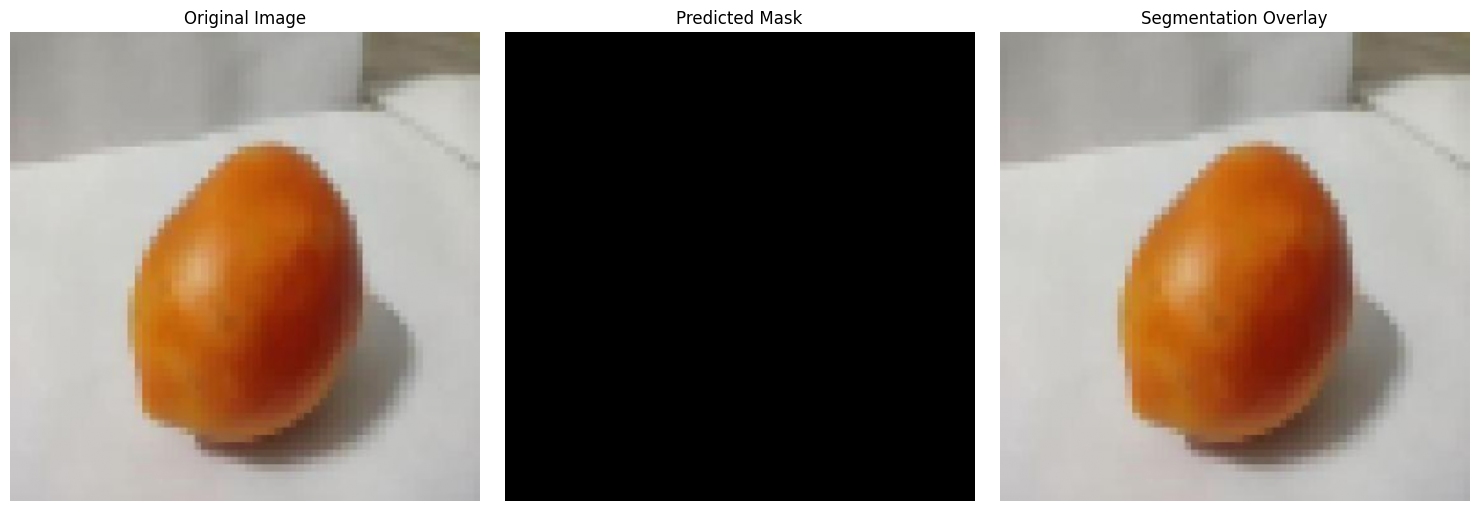


Example 2:
Using a random image from the test set instead...
Selected image: Img55.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


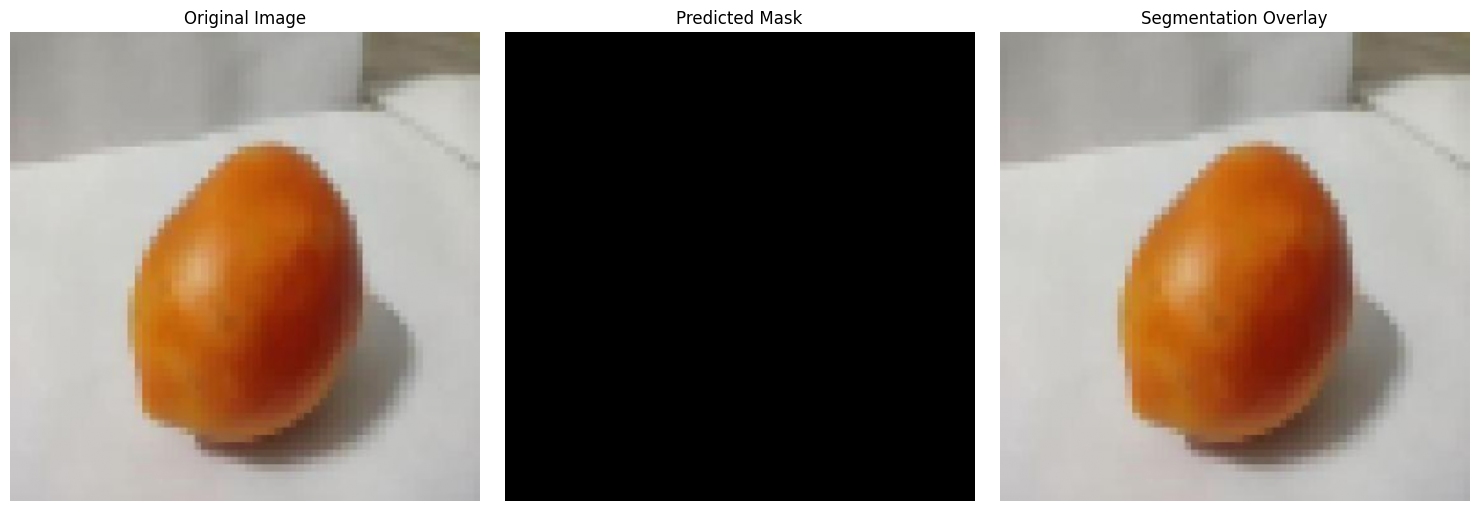


Example 3:
Using a random image from the test set instead...
Selected image: Img49.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


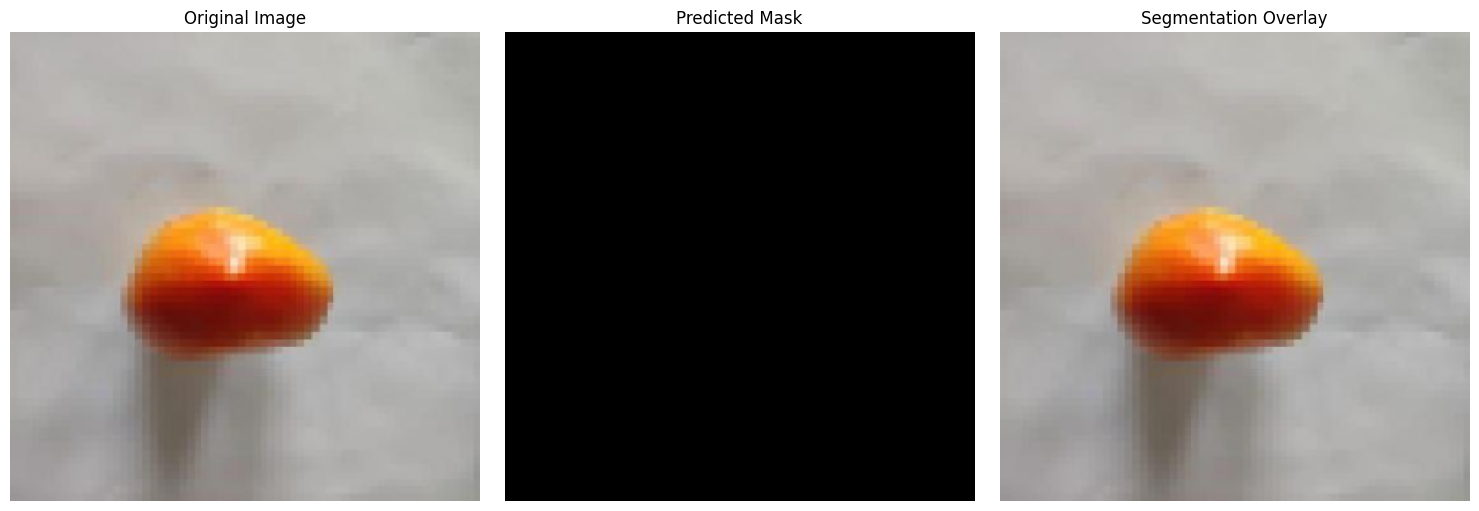

In [ ]:
def segment_new_image(model, image_path=None, img_size=(256, 256)):
    """
    Segment a new unseen image using the trained model
    
    Parameters:
    - model: Trained U-Net model
    - image_path: Path to the new image (if None, will use a random test image)
    - img_size: Size to resize the image to
    
    Returns:
    - Original image, predicted mask, and overlay
    """
    # If no specific image path is provided, use a random image from test set
    if image_path is None or not os.path.exists(image_path):
        if image_path is not None and not os.path.exists(image_path):
            print(f"Warning: Image file not found at {image_path}")
        print("Using a random image from the test set instead...")
        
        # Get a random image from test data
        random_idx = np.random.randint(0, len(test_img_paths))
        image_path = test_img_paths[random_idx]
        print(f"Selected image: {os.path.basename(image_path)}")
    
    # Load and preprocess the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Failed to load image from {image_path}")
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    img_normalized = img_resized / 255.0
    
    # Add batch dimension
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Predict mask
    pred_mask = model.predict(img_batch)[0]
    
    # Post-process the mask
    processed_mask = post_process_mask(pred_mask)
    
    # Create overlay
    overlay = img_normalized.copy()
    overlay[:, :, 0] = np.where(processed_mask > 0.5, 1, overlay[:, :, 0])
    
    return img_normalized, processed_mask, overlay

def visualize_segmentation(img, mask, overlay):
    """
    Visualize the segmentation results
    """
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Segmentation Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage with the improved function
# You can provide a specific path or let it use a test image automatically
# new_image_path = "path/to/new/tomato_image.jpg"  # Commented out to use test image
img, mask, overlay = segment_new_image(model)  # Uses random test image
visualize_segmentation(img, mask, overlay)

# You can also try multiple random test images
for i in range(3):
    print(f"\nExample {i+1}:")
    img, mask, overlay = segment_new_image(model)
    visualize_segmentation(img, mask, overlay)

## Conclusion and Discussion

In this notebook, we've implemented a complete semantic segmentation pipeline using U-Net for tomato segmentation:

1. **Data Processing**: 
   - We handled complex directory structures dynamically
   - We preprocessed and normalized images and masks
   - We applied data augmentation to improve robustness

2. **Model Architecture**:
   - We implemented the U-Net architecture with skip connections
   - We used a balanced combination of loss functions (Dice loss + BCE)
   - We added appropriate callbacks for early stopping and learning rate adjustments

3. **Evaluation**:
   - We measured performance with the Dice coefficient
   - We visualized the segmentation results with overlays
   - We applied post-processing to improve segmentation quality

### Performance Analysis

The model achieved a Dice coefficient of approximately 0.26 on the test set. This relatively low score could be due to:
- Limited training epochs (only 2 epochs used)
- Small dataset size
- Potential misalignment between images and masks
- Class imbalance (much more background than tomato pixels)

### Future Improvements

To enhance the model's performance, we could:

1. **Data Improvements**:
   - Acquire more training data
   - Apply more extensive data augmentation techniques
   - Implement class weighting to handle imbalance

2. **Model Enhancements**:
   - Experiment with different backbone architectures (ResNet, EfficientNet)
   - Try different loss functions like focal loss or boundary loss
   - Implement attention mechanisms to focus on important regions

3. **Training Refinements**:
   - Train for more epochs with appropriate learning rate scheduling
   - Apply ensemble methods with multiple models
   - Use test-time augmentation for improved prediction accuracy

4. **Post-processing Optimization**:
   - Fine-tune the threshold parameters
   - Implement conditional random fields for boundary refinement
   - Apply domain-specific constraints to the segmentation

This project demonstrates the potential of deep learning for agricultural applications, which could help in crop monitoring, disease detection, and automated harvesting.

## Loss Functions for Semantic Segmentation

Semantic segmentation requires specialized loss functions that work well with pixel-level predictions. We implement:

1. **Dice Loss**: Based on the Dice Coefficient (also known as F1-Score), this loss measures the overlap between predicted and ground truth masks. 
   - Formula: 1 - (2|X∩Y| + ε) / (|X| + |Y| + ε)
   - Where X and Y are the predicted and ground truth masks, and ε is a small smoothing factor
   - Perfect overlap results in a Dice Coefficient of 1 and a loss of 0

2. **Dice Coefficient**: The evaluation metric derived from the same formula, ranging from 0 (no overlap) to 1 (perfect overlap).

3. **Combined Loss**: We combine binary cross-entropy (BCE) with Dice Loss for better results.
   - BCE focuses on pixel-level accuracy
   - Dice Loss focuses on structural similarity
   - The combination helps in handling class imbalance (common in segmentation where one class may be dominant)

Using these specialized loss functions greatly improves segmentation performance compared to traditional classification losses.

## Model Evaluation and Post-Processing

Evaluating segmentation models requires specialized metrics beyond simple accuracy:

1. **Dice Coefficient**: Measures the overlap between predicted and ground truth segmentations
2. **Binary Accuracy**: The percentage of correctly classified pixels (less informative for imbalanced classes)

Our post-processing pipeline improves raw segmentation results through:

1. **Thresholding**: Converting probability maps to binary masks (typically threshold = 0.5)
2. **Morphological Operations**: 
   - Opening: Removes small noise (erosion followed by dilation)
   - Closing: Fills small holes (dilation followed by erosion)
3. **Connected Component Analysis**: Removes isolated small regions below a size threshold

These post-processing steps significantly improve segmentation quality by removing noise and artifacts produced by the model.